In [10]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, vstack, Column, join
from astropy.cosmology import Planck18 as cosmo
from scipy.stats import binned_statistic

In [2]:
#embedding_path = 'desi_bgs_embeddings_011426.csv'
#embedding_path = 'desi_bgs_embeddings_020226_subsampled.csv'
embedding_path = 'desi_lrg_embeddings.csv'

# DR1 galaxy catalogs (must be run on NERSC)
#gal_info_path = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/BGS_BRIGHT_full.dat.fits'  
gal_info_path = '/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/LRG_full.dat.fits'

gal_embedding = Table.read(embedding_path)
gal_info = Table.read(gal_info_path)

Selecting and adding relevant columns to the galaxy catalog

Description of columns: https://www.legacysurvey.org/dr10/files/

In [ ]:
gal_info.rename_column('Z_not4clus', 'Z')
gal_info.keep_columns(['TARGETID', 'RA', 'DEC', 'Z', 'MORPHTYPE', 'SHAPE_R',
                       'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
                       'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2'])
# add colums for colors
def get_color(flux1, trans1, flux2, trans2):
    return -2.5 * np.log10((flux1 * trans1) / (flux2 * trans2))

gal_info['G-R'] = get_color(gal_info['FLUX_G'], gal_info['MW_TRANSMISSION_G'],
                            gal_info['FLUX_R'], gal_info['MW_TRANSMISSION_R'])
gal_info['R-Z'] = get_color(gal_info['FLUX_R'], gal_info['MW_TRANSMISSION_R'],
                            gal_info['FLUX_Z'], gal_info['MW_TRANSMISSION_Z'])
gal_info['Z-W1'] = get_color(gal_info['FLUX_Z'], gal_info['MW_TRANSMISSION_Z'],
                             gal_info['FLUX_W1'], gal_info['MW_TRANSMISSION_W1'])
gal_info['W1-W2'] = get_color(gal_info['FLUX_W1'], gal_info['MW_TRANSMISSION_W1'],
                              gal_info['FLUX_W2'], gal_info['MW_TRANSMISSION_W2'])

# get absolute magnitude
def get_apparent_mag(flux, trans):
    return 22.5 - 2.5 * np.log10(flux * trans)

gal_info['mag_G'] = get_apparent_mag(gal_info['FLUX_G'], gal_info['MW_TRANSMISSION_G'])
gal_info['mag_R'] = get_apparent_mag(gal_info['FLUX_R'], gal_info['MW_TRANSMISSION_R'])
gal_info['mag_Z'] = get_apparent_mag(gal_info['FLUX_Z'], gal_info['MW_TRANSMISSION_Z'])

# Calculate distance modulus from redshift
d_L = cosmo.luminosity_distance(gal_info['Z']).to('pc').value
dist_mod = 5 * np.log10(d_L) - 5

# Calculate absolute magnitudes
gal_info['M_G'] = gal_info['mag_G'] - dist_mod
gal_info['M_R'] = gal_info['mag_R'] - dist_mod
gal_info['M_Z'] = gal_info['mag_Z'] - dist_mod

/tmp/ipykernel_1003262/4231690580.py:7: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10((flux1 * trans1) / (flux2 * trans2))
/tmp/ipykernel_1003262/4231690580.py:7: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10((flux1 * trans1) / (flux2 * trans2))
/tmp/ipykernel_1003262/4231690580.py:7: RuntimeWarning: divide by zero encountered in divide
  return -2.5 * np.log10((flux1 * trans1) / (flux2 * trans2))
/tmp/ipykernel_1003262/4231690580.py:20: RuntimeWarning: divide by zero encountered in log10
  return 22.5 - 2.5 * np.log10(flux * trans)
/tmp/ipykernel_1003262/4231690580.py:20: RuntimeWarning: invalid value encountered in log10
  return 22.5 - 2.5 * np.log10(flux * trans)
/global/common/software/desi/users/clamman/perlmutter/cosmodesiconda/20240519-1.0.0/conda/lib/python3.10/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = u

Join the embedding and galaxy property table. For the full catalog, there should be a match for each galaxy.

In [4]:
print(len(gal_embedding))
joined_table = join(gal_embedding, gal_info, keys='TARGETID', join_type='inner')
print(len(joined_table))

11185
11185


In [5]:
# round all values in joined table to 4 decimal places
joined_table.round(4)

In [6]:
# going to remove these so they don't show up in the plots. 
joined_table.remove_columns(['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2'])
joined_table.remove_columns(['FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2'])
joined_table.remove_columns(['mag_G', 'mag_R', 'mag_Z'])
joined_table

TARGETID,embedding_1,embedding_2,embedding_3,Z,MORPHTYPE,RA,DEC,SHAPE_R,G-R,R-Z,Z-W1,W1-W2,M_G,M_R,M_Z
int64,float64,float64,float64,float64,bytes4,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64
39627655082937362,-0.3365,-0.9306,-0.3954,0.5949,SER,185.4283,-5.4561,4.37,1.9959,1.4296,1.0506,-0.698,-20.9766,-22.9725,-24.4021
39627655082938614,-0.1799,-1.2602,-0.1901,0.5931,DEV,185.4941,-5.5569,0.9697,1.8556,1.3493,1.0748,-0.6205,-20.3979,-22.2535,-23.6027
39627655137462369,1.8815,1.4532,-1.146,0.6073,SER,188.6269,-5.4332,3.1478,2.0296,1.5231,1.055,-0.6483,-20.5667,-22.5962,-24.1193
39627655137464362,0.8108,-0.7814,0.9377,0.6161,REX,188.7238,-5.4159,1.0828,1.4664,1.2335,1.4592,-0.5944,-21.1762,-22.6426,-23.8761
39627655183597780,1.0834,-0.5503,0.8496,0.6132,REX,191.3046,-5.3985,0.4592,1.8039,1.4382,1.1597,-0.6681,-20.0064,-21.8103,-23.2485
39627655187796234,1.0688,-0.5957,0.9262,0.6022,DEV,191.7616,-5.4816,0.8853,1.9566,1.46,1.2171,-0.6001,-20.2398,-22.1964,-23.6563
39627661076596124,0.7327,-0.8016,0.3071,0.6353,DEV,183.8179,-5.1448,0.893,1.9531,1.5889,1.2834,-0.7181,-19.75,-21.7031,-23.292
39627661076596354,1.5807,0.3179,0.6907,0.5814,SER,183.8267,-5.3693,1.1648,1.851,1.3103,1.1202,-0.5454,-20.1081,-21.9591,-23.2693
39627661076596883,-0.6031,-1.1277,-0.5784,0.6086,DEV,183.8508,-5.1644,1.2038,1.8284,1.3819,1.4703,-0.3864,-20.0037,-21.8321,-23.2139


Looking at relationship between gal properties and embeddings

In [7]:
joined_table.columns[4:] # all the columns to plot against embeddings

<TableColumns names=('Z','MORPHTYPE','RA','DEC','SHAPE_R','G-R','R-Z','Z-W1','W1-W2','M_G','M_R','M_Z')>

In [9]:
# remove any row where any value is nan or inf or 0
for c in joined_table.columns:
    if c == 'MORPHTYPE':
        continue
    col = joined_table[c]
    mask = np.isfinite(col) & (col != 0) & (~np.isnan(col))
    joined_table = joined_table[mask]

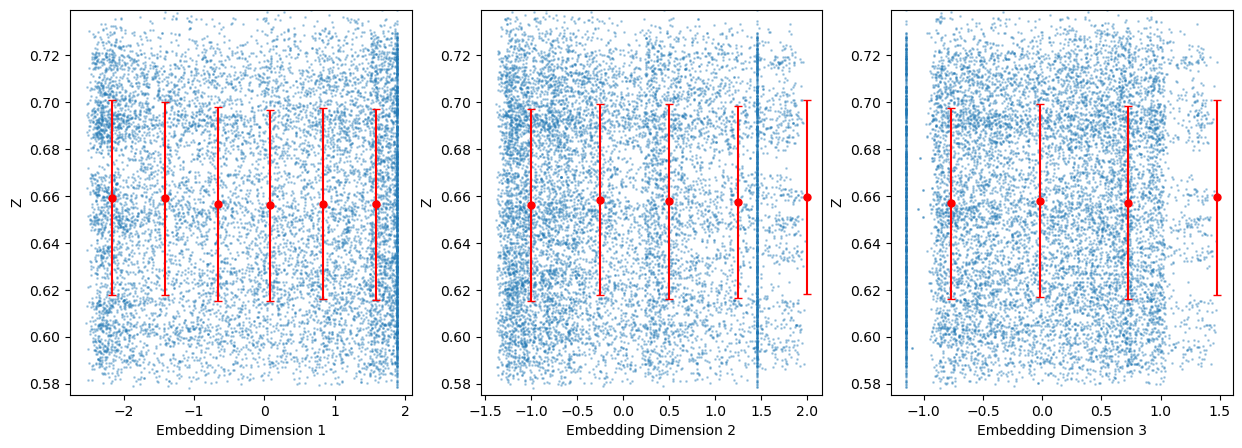

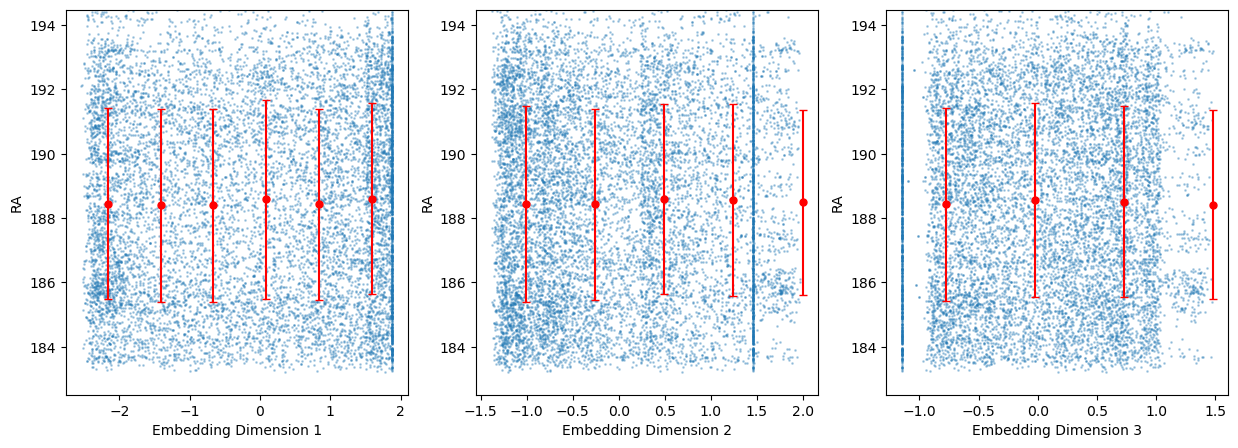

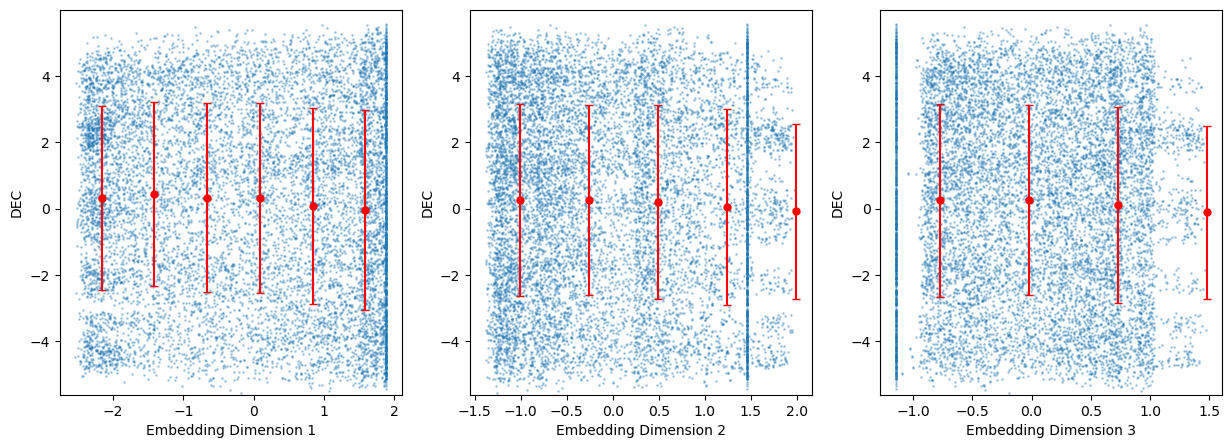

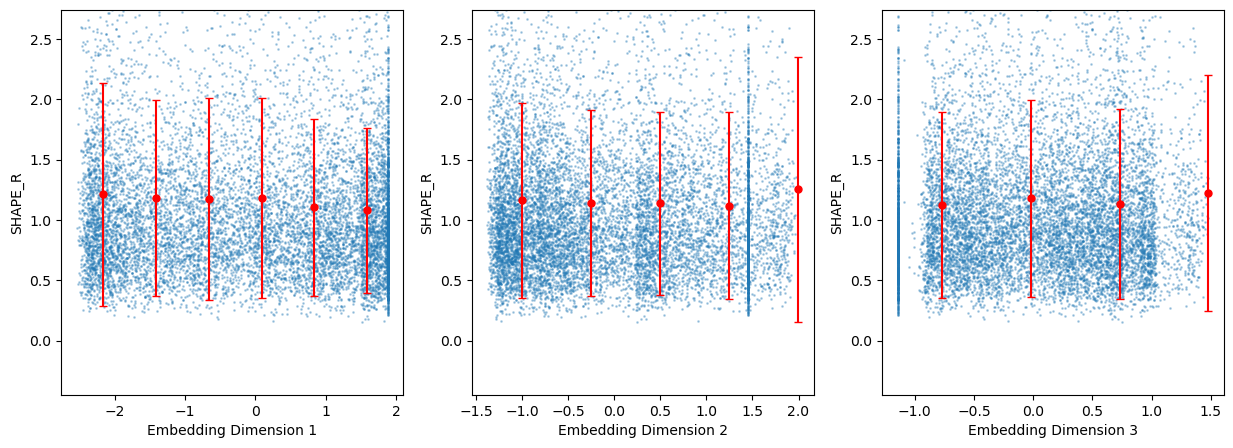

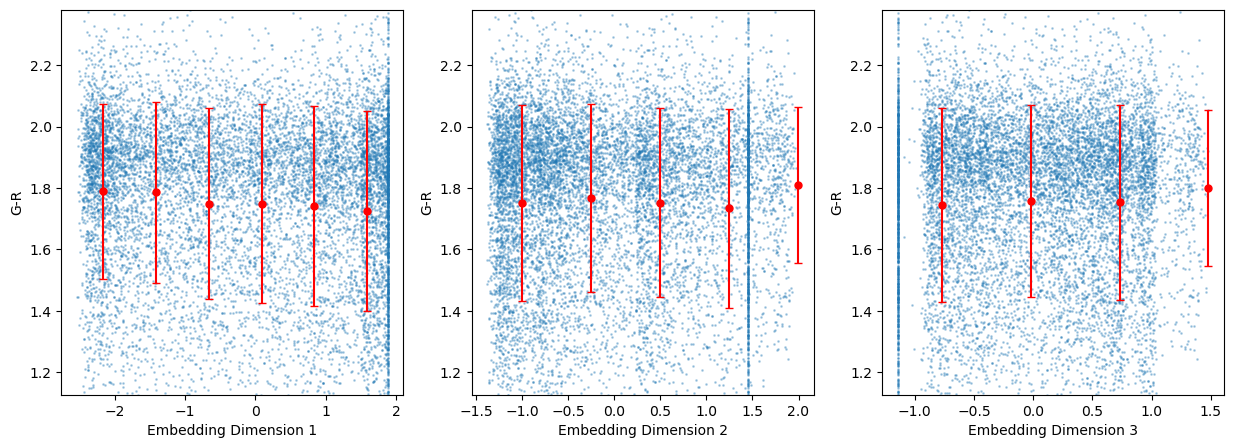

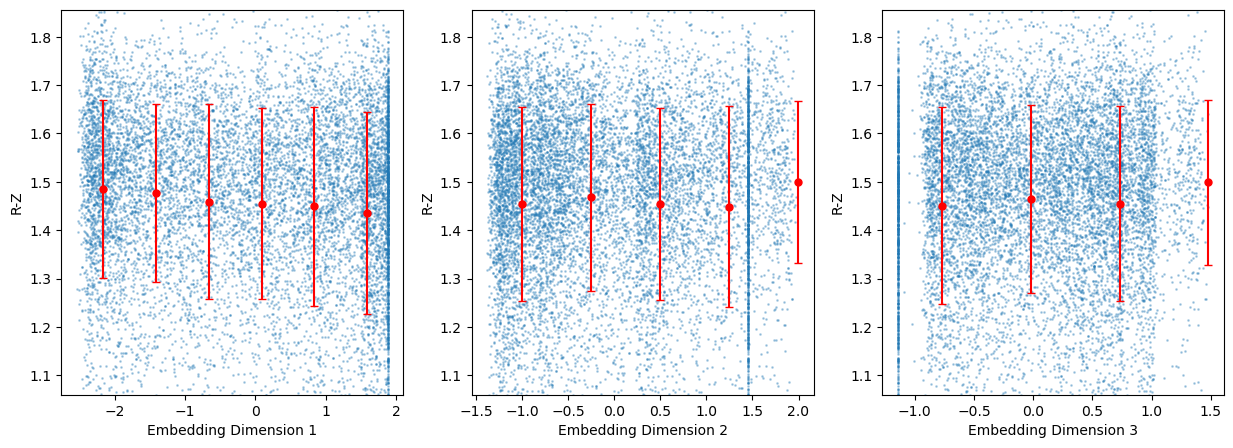

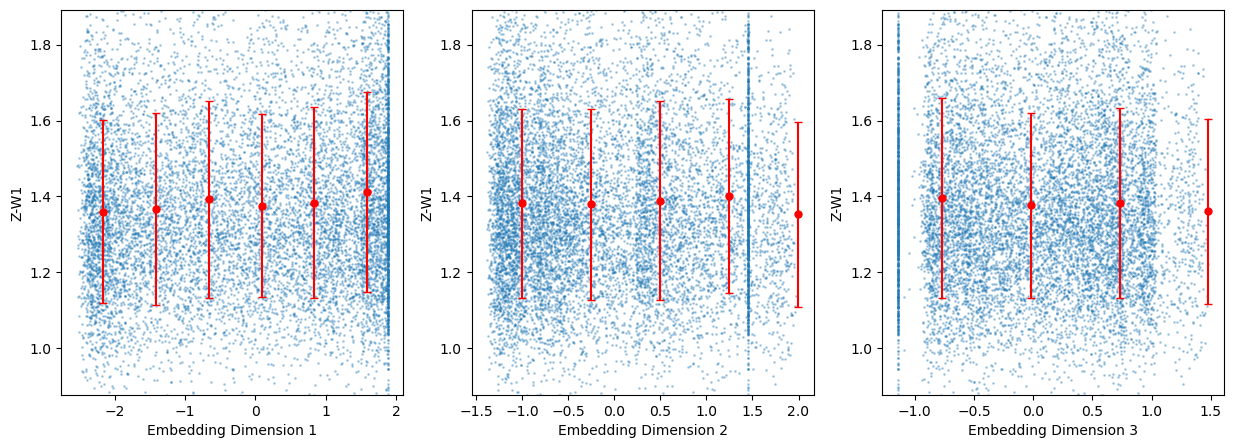

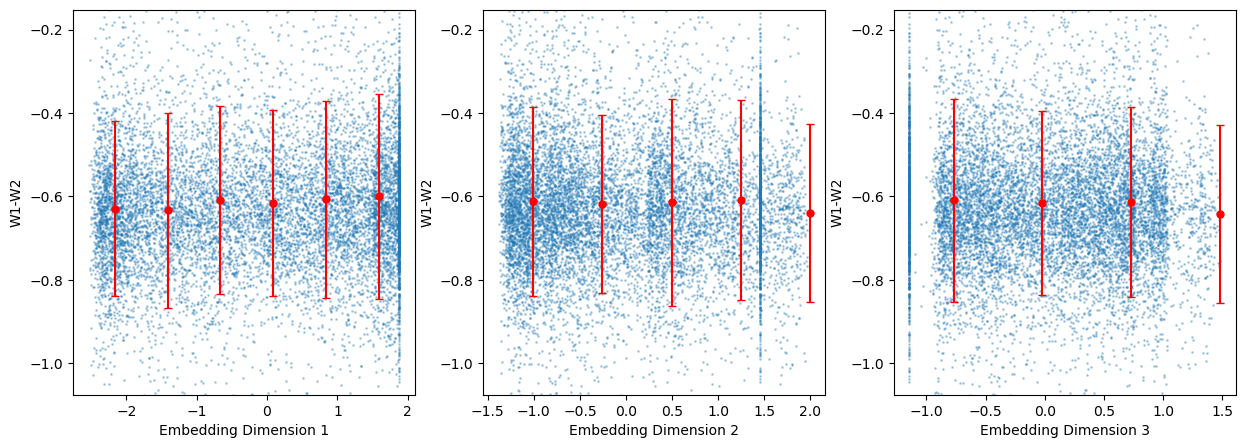

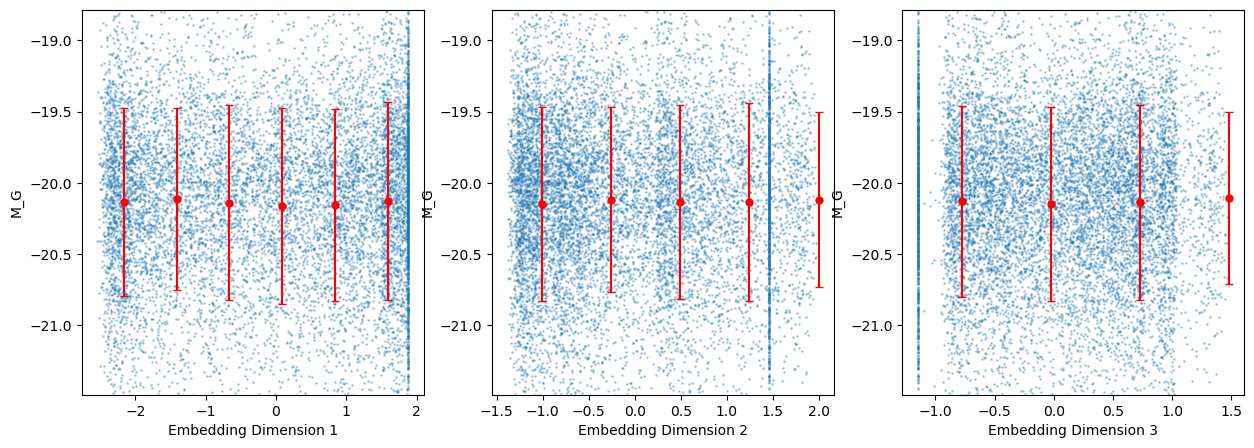

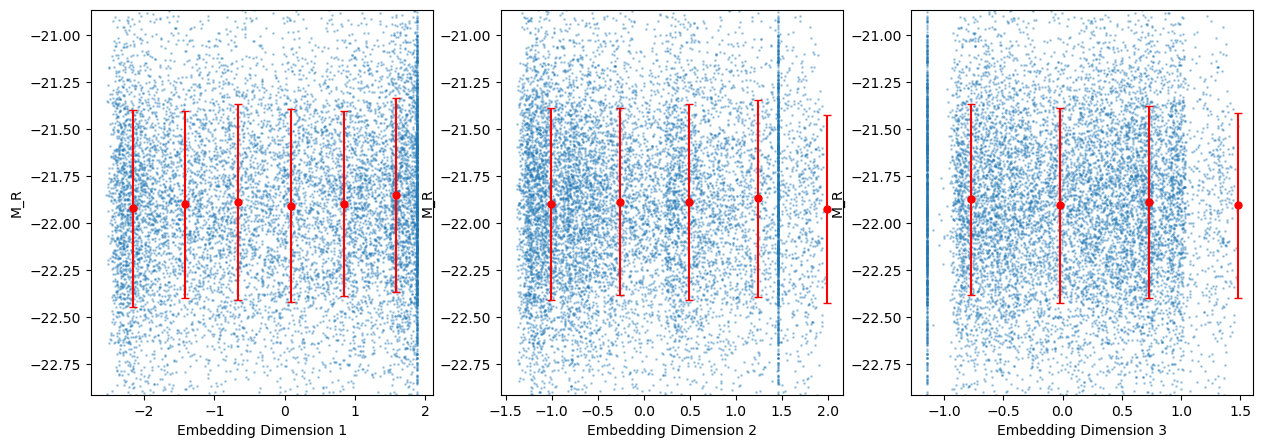

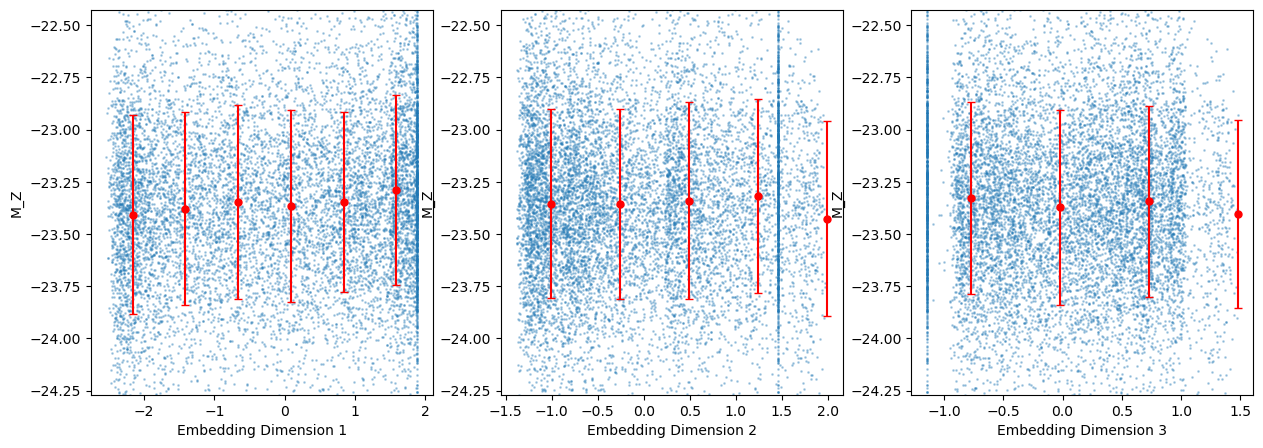

In [11]:
# plot parameters
s = 1
alpha=.3
bin_width = .75

for column in joined_table.columns[4:]:
    
    if column == 'MORPHTYPE':   # not a physical variable, will look at in more detail below
        continue
    
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5))
    y = np.array(joined_table[column])
    
    # Embedding 1 vs column
    x1 = np.array(joined_table['embedding_1'])
    mask1 = np.isfinite(x1) & np.isfinite(y)
    scatter = ax1.scatter(x1, y, s=s, alpha=alpha)
    bins1 = np.arange(np.nanmin(x1), np.nanmax(x1) + bin_width, bin_width)
    bin_means1, bin_edges1, _ = binned_statistic(x1[mask1], y[mask1], statistic='mean', bins=bins1)
    bin_stds1, _, _ = binned_statistic(x1[mask1], y[mask1], statistic='std', bins=bins1)
    bin_centers1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2
    ax1.errorbar(bin_centers1, bin_means1, yerr=bin_stds1, fmt='ro', markersize=5, capsize=3)
    ax1.set_xlabel('Embedding Dimension 1')
    ax1.set_ylabel(column)
    
    # Embedding 2 vs column
    x2 = np.array(joined_table['embedding_2'])
    mask2 = np.isfinite(x2) & np.isfinite(y)
    scatter = ax2.scatter(x2, y, s=s, alpha=alpha)
    bins2 = np.arange(np.nanmin(x2), np.nanmax(x2) + bin_width, bin_width)
    bin_means2, bin_edges2, _ = binned_statistic(x2[mask2], y[mask2], statistic='mean', bins=bins2)
    bin_stds2, _, _ = binned_statistic(x2[mask2], y[mask2], statistic='std', bins=bins2)
    bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
    ax2.errorbar(bin_centers2, bin_means2, yerr=bin_stds2, fmt='ro', markersize=5, capsize=3)
    ax2.set_xlabel('Embedding Dimension 2')
    ax2.set_ylabel(column)
    
    # Embedding 3 vs column
    x3 = np.array(joined_table['embedding_3'])
    mask3 = np.isfinite(x3) & np.isfinite(y)
    scatter = ax3.scatter(x3, y, s=s, alpha=alpha)
    bins3 = np.arange(np.nanmin(x3), np.nanmax(x3) + bin_width, bin_width)
    bin_means3, bin_edges3, _ = binned_statistic(x3[mask3], y[mask3], statistic='mean', bins=bins3)
    bin_stds3, _, _ = binned_statistic(x3[mask3], y[mask3], statistic='std', bins=bins3)
    bin_centers3 = (bin_edges3[:-1] + bin_edges3[1:]) / 2
    ax3.errorbar(bin_centers3, bin_means3, yerr=bin_stds3, fmt='ro', markersize=5, capsize=3)
    ax3.set_xlabel('Embedding Dimension 3')
    ax3.set_ylabel(column)
    
    # Limit y-axis to 2 sigma of values
    mean = np.nanmean(joined_table[column])
    std = np.nanstd(joined_table[column])
    y_min = mean - 2 * std
    y_max = mean + 2 * std
    
    for ax in [ax1, ax2, ax3]:
            ax.set_ylim(y_min, y_max)

Now looking at morphology. This is the light profile chosen for each galaxy and is a mix of its physical morphology and imaging systematics.

DEV
EXP
REX
SER


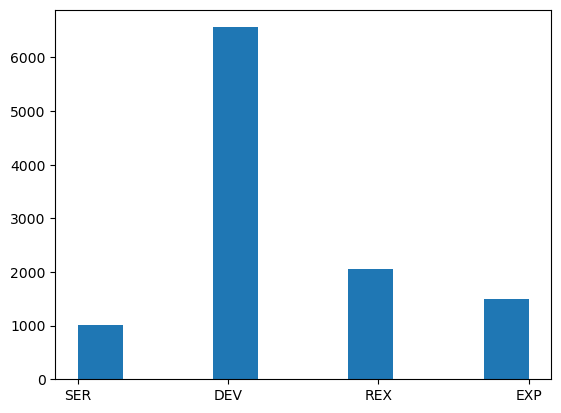

In [12]:
# looking at morphology
plt.hist(joined_table['MORPHTYPE']);
# make a stacked histogram where each bar of the morphology histogram contains the relative fraction of each embedding
morph_types = np.unique(joined_table['MORPHTYPE'])
morph_types 

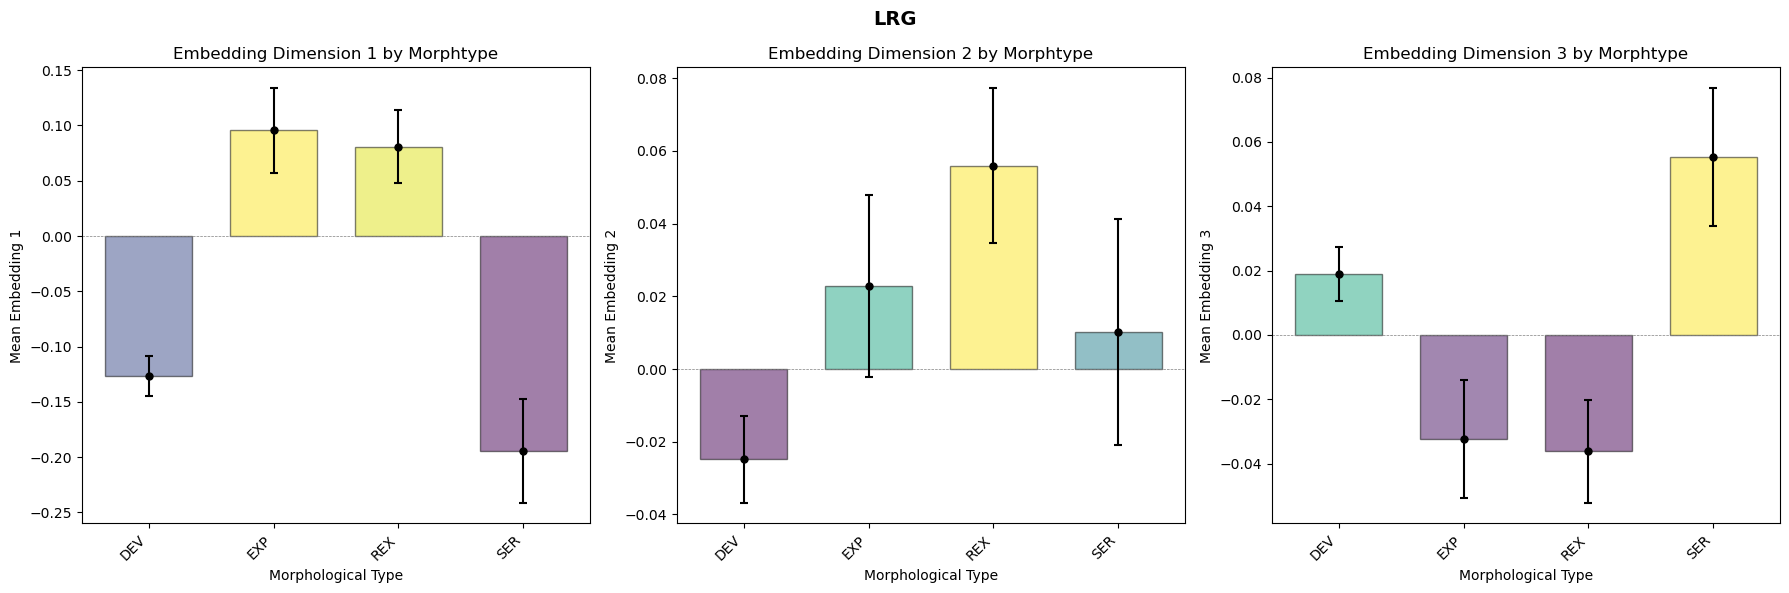

In [13]:
# 3 separate bar charts for each embedding dimension
morph_types = np.unique(joined_table['MORPHTYPE'])

# Calculate mean and standard error for each morphtype and embedding
emb_data = {'embedding_1': [], 'embedding_2': [], 'embedding_3': []}
emb_se = {'embedding_1': [], 'embedding_2': [], 'embedding_3': []}

for morph in morph_types:
    mask = joined_table['MORPHTYPE'] == morph
    n = np.sum(mask)
    for emb in emb_data.keys():
        mean_val = np.mean(joined_table[emb][mask])
        std_val = np.std(joined_table[emb][mask])
        se_val = std_val / np.sqrt(n)
        emb_data[emb].append(mean_val)
        emb_se[emb].append(se_val)

# Convert to arrays
for emb in emb_data.keys():
    emb_data[emb] = np.array(emb_data[emb])
    emb_se[emb] = np.array(emb_se[emb])

# Create 3 separate bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('LRG', fontsize=14, fontweight='bold')
x = np.arange(len(morph_types))

width = 0.7

for i, (emb, ax) in enumerate(zip(['embedding_1', 'embedding_2', 'embedding_3'], axes)):
    means = emb_data[emb]
    ses = emb_se[emb]
    
    # Color bars by their mean value
    norm = plt.Normalize(means.min(), means.max())
    colors = plt.cm.viridis(norm(means))
    
    bars = ax.bar(x, means, width, color=colors, edgecolor='black', alpha=.5)
    
    # Add error bars as scatter points with error bars
    ax.errorbar(x, means, yerr=ses, fmt='ko', markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=5)
    
   
    
    ax.set_xlabel('Morphological Type')
    ax.set_ylabel(f'Mean {emb.replace("_", " ").title()}')
    ax.set_title(f'Embedding Dimension {i+1} by Morphtype')
    ax.set_xticks(x)
    ax.set_xticklabels(morph_types, rotation=45, ha='right')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap='viridis')
    sm.set_array([])
    #plt.colorbar(sm, ax=ax, label='Mean Value')

plt.tight_layout()
plt.show()

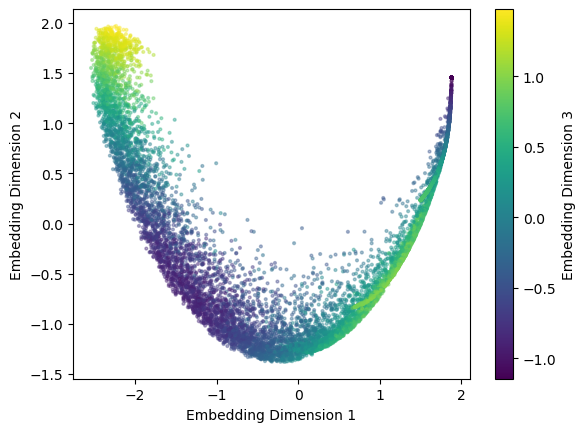

In [33]:
plt.scatter(joined_table['embedding_1'], joined_table['embedding_2'], c=joined_table['embedding_3'], s=4, alpha=.4, rasterized=True);
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
cb = plt.colorbar(label='Embedding Dimension 3')
cb.solids.set_alpha(1)